In [1]:
import os 
import torch 
import numpy as np 
import pandas as pd 
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import get_peft_model, LoraConfig, TaskType
from torch.optim import AdamW
from sklearn.metrics import f1_score, classification_report

print("Imported all libraries!")

Imported all libraries!


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [3]:
dataset = load_dataset('surrey-nlp/BESSTIE-CW-26')

train_df = pd.DataFrame(dataset['train'])
val_df   = pd.DataFrame(dataset['validation'])
test_df  = pd.DataFrame(dataset['test'])

train_df['Sarcasm'] = train_df['Sarcasm'].astype(int)
val_df['Sarcasm']   = val_df['Sarcasm'].astype(int)
test_df['Sarcasm']  = test_df['Sarcasm'].astype(int)

train_uk = train_df[train_df['variety'] == 'en-UK']
train_au = train_df[train_df['variety'] == 'en-AU']
train_in = train_df[train_df['variety'] == 'en-IN']

test_uk = test_df[test_df['variety'] == 'en-UK']
test_au = test_df[test_df['variety'] == 'en-AU']
test_in = test_df[test_df['variety'] == 'en-IN']

print("Train sizes - UK:", len(train_uk))
print("Train sizes - AU:", len(train_au))
print("Train sizes - IN:", len(train_in))

print("Test sizes - UK:", len(test_uk))
print("Test sizes - AU:", len(test_au))
print("Test sizes - IN:", len(test_in))

Train sizes - UK: 1203
Train sizes - AU: 1145
Train sizes - IN: 1399
Test sizes - UK: 700
Test sizes - AU: 667
Test sizes - IN: 816


In [4]:
model_name = 'models/qwen2.5-1.5b'
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Qwen2.5 does not have a pad token by default so we used EOF token as pad token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

class SarcasmDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len # Number of token per sequence 

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Tokenized one sample at a time
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True, # Cares about sequences longer than max_len
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        # Squeeze removes the extra batch dimension added by return_tensors='pt'
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long) # Convert to tensor for cross entropy loss
        }

print("Tokenizer and dataset class ready")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Tokenizer and dataset class ready


In [5]:
from peft import get_peft_model, LoraConfig, TaskType

def load_lora_model():
    # Load the base Qwen2.5-1.5B model with a classification head (2 labels: sarcastic/not sarcastic)
    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )
    # Set pad token id so the model knows which tokens to ignore during attention
    base_model.config.pad_token_id = tokenizer.pad_token_id

    '''
    task_type=SEQ_CLS -> tells teh PEFT this is a sequence classification task
    r=8 -> rank of the lower matrices 
    lora_alpha=16 is the scaling factor — effective scale = alpha/r = 16/8 = 2
    arget_modules: we only adapt query and value projections in the attention layers
    '''
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=['q_proj', 'v_proj']
    )

    model = get_peft_model(base_model, lora_config)
    model.print_trainable_parameters()
    return model

print("Model loaded!")

Model loaded!


In [6]:
def train_epoch(model, loader, optimizer, class_weights):
    model.train()
    total_loss = 0
    criterion  = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

    for batch in loader: 
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [7]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [8]:
def train_lora_adapter(train_df, variety_name):
    print(f"Training LoRA adapter for {variety_name}...")

    texts = train_df['text'].tolist()
    labels = train_df['Sarcasm'].tolist()

    n_total = len(labels)
    n_neg = labels.count(0)
    n_pos = labels.count(1)
    w0 = n_total / (2 * n_neg)
    w1 = n_total / (2 * n_pos)
    class_weights = torch.tensor([w0, w1], dtype=torch.float)
    print(f"Class weights - Not Sarcastic: {w0:.2f}")
    print(f"Class weights - Sarcastic: {w1:.2f}")

    dataset = SarcasmDataset(texts, labels, tokenizer)
    loader = DataLoader(dataset, batch_size=8, shuffle=True)

    model = load_lora_model()
    model = model.to(device)
    optimizer = AdamW(model.parameters(), lr=2e-4)

    for epoch in range(3):
        loss = train_epoch(model, loader, optimizer, class_weights)
        labels_out, preds_out = evaluate(model, loader)
        f1 = f1_score(labels_out, preds_out, average='macro')
        print(f"Epoch {epoch+1}/3 - Loss: {loss:.4f} - Train F1: {f1:.4f}")

    save_path = f'models/lora_{variety_name.replace("-", "_")}'
    model.save_pretrained(save_path)
    print(f"Adapter saved to {save_path}")

    # clear GPU memory
    del model, optimizer
    torch.cuda.empty_cache()

    return save_path


path_uk = train_lora_adapter(train_uk, 'en-UK')
path_au = train_lora_adapter(train_au, 'en-AU')
path_in = train_lora_adapter(train_in, 'en-IN')

Training LoRA adapter for en-UK...
Class weights - Not Sarcastic: 0.54
Class weights - Sarcastic: 6.54


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,092,608 || all params: 1,544,809,984 || trainable%: 0.07072766303405766
Epoch 1/3 - Loss: 0.5689 - Train F1: 0.7460
Epoch 2/3 - Loss: 0.2500 - Train F1: 0.6992
Epoch 3/3 - Loss: 0.1266 - Train F1: 0.9585
Adapter saved to models/lora_en_UK
Training LoRA adapter for en-AU...
Class weights - Not Sarcastic: 0.71
Class weights - Sarcastic: 1.70


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,092,608 || all params: 1,544,809,984 || trainable%: 0.07072766303405766
Epoch 1/3 - Loss: 0.6907 - Train F1: 0.7629
Epoch 2/3 - Loss: 0.4268 - Train F1: 0.9188
Epoch 3/3 - Loss: 0.1935 - Train F1: 0.9793
Adapter saved to models/lora_en_AU
Training LoRA adapter for en-IN...
Class weights - Not Sarcastic: 0.54
Class weights - Sarcastic: 7.36


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,092,608 || all params: 1,544,809,984 || trainable%: 0.07072766303405766
Epoch 1/3 - Loss: 0.8950 - Train F1: 0.6685
Epoch 2/3 - Loss: 0.3396 - Train F1: 0.5112
Epoch 3/3 - Loss: 0.1890 - Train F1: 0.9757
Adapter saved to models/lora_en_IN


In [9]:
from peft import PeftModel

def load_adapter_and_evaluate(adapter_path, test_df, test_variety):
    # Load a freash base model for each evaluation 
    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )
    base_model.config.pad_token_id = tokenizer.pad_token_id

    # Load the saved LoRA adapter weights on top of the frozen base model
    model = PeftModel.from_pretrained(base_model, adapter_path)
    model = model.to(device)
    model.eval()

    texts = test_df['text'].tolist()
    labels = test_df['Sarcasm'].tolist()

    dataset = SarcasmDataset(texts, labels, tokenizer)
    loader = DataLoader(dataset, batch_size=8, shuffle=False)

    true_labels, preds = evaluate(model, loader)
    f1 = f1_score(true_labels, preds, average='macro')

    del model
    torch.cuda.empty_cache()

    return round(f1, 4)


adapters = [path_uk, path_au, path_in]
varieties = ['en-UK', 'en-AU', 'en-IN']
test_dfs = [test_uk, test_au, test_in]

lora_results = {}
for adapter_path, train_variety in zip(adapters, varieties):
    lora_results[train_variety] = {}
    for test_df, test_variety in zip(test_dfs, varieties):
        f1 = load_adapter_and_evaluate(adapter_path, test_df, test_variety)
        lora_results[train_variety][test_variety] = f1
        print(f"Train: {train_variety} - Test: {test_variety} - F1: {f1}")

Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Train: en-UK - Test: en-UK - F1: 0.6767


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Train: en-UK - Test: en-AU - F1: 0.5797


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Train: en-IN - Test: en-UK - F1: 0.6276


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Train: en-IN - Test: en-AU - F1: 0.5234


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Train: en-IN - Test: en-IN - F1: 0.5944


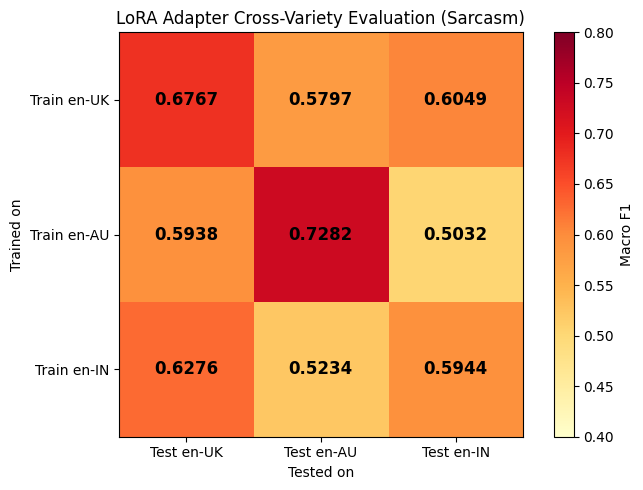

In [17]:
import matplotlib.pyplot as plt
import numpy as np 

varieties = ['en-UK', 'en-AU', 'en-IN']

matrix = []
for train_variety in varieties: 
    row = []
    for test_variety in varieties:
        value = lora_results[train_variety][test_variety]
        row.append(value)
    matrix.append(row)

matrix = np.array(matrix)

fig, ax = plt.subplots(figsize = (7, 5))
im = ax.imshow(matrix, cmap='YlOrRd', vmin=0.4, vmax=0.8)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Test en-UK', 'Test en-AU', 'Test en-IN'])
ax.set_yticklabels(['Train en-UK', 'Train en-AU', 'Train en-IN'])

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(matrix[i, j]), ha='center', va='center', fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax, label='Macro F1')
ax.set_title('LoRA Adapter Cross-Variety Evaluation (Sarcasm)')
ax.set_xlabel('Tested on')
ax.set_ylabel('Trained on')
plt.tight_layout()
plt.savefig('figures/lora_cross_variety_matrix.png', dpi=150)
plt.show()

In [19]:
# Run 2 - loRA Adapters 
torch.manual_seed(0)

path_uk_run2 = train_lora_adapter(train_uk, 'en-UK-run2')
path_au_run2 = train_lora_adapter(train_au, 'en-AU-run2')
path_in_run2 = train_lora_adapter(train_in, 'en-IN-run2')

print("Done!")

Training LoRA adapter for en-UK-run2...
Class weights - Not Sarcastic: 0.54
Class weights - Sarcastic: 6.54


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,092,608 || all params: 1,544,809,984 || trainable%: 0.07072766303405766
Epoch 1/3 - Loss: 0.6217 - Train F1: 0.7427
Epoch 2/3 - Loss: 0.2839 - Train F1: 0.7949
Epoch 3/3 - Loss: 0.1278 - Train F1: 0.9322
Adapter saved to models/lora_en_UK_run2
Training LoRA adapter for en-AU-run2...
Class weights - Not Sarcastic: 0.71
Class weights - Sarcastic: 1.70


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,092,608 || all params: 1,544,809,984 || trainable%: 0.07072766303405766
Epoch 1/3 - Loss: 0.7896 - Train F1: 0.7833
Epoch 2/3 - Loss: 0.3864 - Train F1: 0.8230
Epoch 3/3 - Loss: 0.1880 - Train F1: 0.9958
Adapter saved to models/lora_en_AU_run2
Training LoRA adapter for en-IN-run2...
Class weights - Not Sarcastic: 0.54
Class weights - Sarcastic: 7.36


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,092,608 || all params: 1,544,809,984 || trainable%: 0.07072766303405766
Epoch 1/3 - Loss: 0.7128 - Train F1: 0.6533
Epoch 2/3 - Loss: 0.2912 - Train F1: 0.6979
Epoch 3/3 - Loss: 0.1200 - Train F1: 0.9888
Adapter saved to models/lora_en_IN_run2
Done!


In [25]:
uk_run2_f1 = load_adapter_and_evaluate('models/lora_en_UK_run2', test_uk, 'en-UK')
au_run2_f1 = load_adapter_and_evaluate('models/lora_en_AU_run2', test_au, 'en-AU')
in_run2_f1 = load_adapter_and_evaluate('models/lora_en_IN_run2', test_in, 'en-IN')

print(" --- Two Run Comparison --- ")
print(f"en-UK -> Run 1: {lora_results['en-UK']['en-UK']} vs Run 2: {uk_run2_f1}")
print(f"en-AU -> Run 1: {lora_results['en-AU']['en-AU']} vs Run 2: {au_run2_f1}")
print(f"en-IN -> Run 1: {lora_results['en-IN']['en-IN']} vs Run 2: {in_run2_f1}")

Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at models/qwen2.5-1.5b and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 --- Two Run Comparison --- 
en-UK -> Run 1: 0.6767 vs Run 2: 0.6992
en-AU -> Run 1: 0.7282 vs Run 2: 0.7375
en-IN -> Run 1: 0.5944 vs Run 2: 0.6075
